- BLOK A — cechy naprawdę istotne (liniowe)         [X1, X2, X3]
- BLOK B — cechy istotne nieliniowo                  [X4, X5]
- BLOK C — cechy istotne przez interakcję           [X6, X7]
- BLOK D — cechy skorelowane z istotnymi            [X8–X12]
- BLOK E — cechy o niskiej wariancji (prawie stałe) [X13, X14]
- BLOK F — czysty szum                    [X15–X25]
- BLOK G — cechy dyskretne / kategoryczne           [X26–X30]

- BLOK A
    - X1 ~ N(0,1)
    - X2 ~ N(0,1)
    - X3 ~ Exp(λ=1)
- BLOK B
    - X4 ~ N(0,1)
    - X5 ~ U(-3, 3)
- BLOK C
    - X6 ~ N(0,1)
    - X7 ~ N(0,1)
- BLOK D
    - X8 = $0.95 \cdot X_1 + \sqrt{1 - 0.95^2} \cdot \mathcal{N}(0, 1)$ - silna korelacja z X1
    - X9 = $0.80 \cdot X_1 + \sqrt{1 - 0.80^2} \cdot \mathcal{N}(0, 1)$ - trochę słabsza korelacja z X1
    - X10 = $0.90 \cdot X_4 + \sqrt{1 - 0.90^2} \cdot \mathcal{N}(0, 1)$ - korelacja ze zmienna istotną nieliniowo
    - X11 = $0.80 \cdot X_6 + \sqrt{1 - 0.80^2} \cdot \mathcal{N}(0, 1)$ - korelacja z połową interakcji
    - X12 = $0.50 \cdot X_3 + 0.50 \cdot X_1 + \sqrt{1 - 0.5^2 - 0.5^2} \cdot \mathcal{N}(0, 1)$ - kobminacja liniowa dwóch zmiennych 
- BLOK E
    - X13 ~ N(0,0.01) - istotna o niskiej wariancji
    - X14 ~ N(0.0.005) - nieistotna
- BLOK F
    - $X_{15} \dots X_{20} \sim \mathcal{N}(0, 1)$ - szum gausowski
    - X21-X23 ~ U(-2,2) - szum jednostajny
    - X24-X25 ~ N(0,1) - skorelowane ze sobą 
- BLOK G
    - X26 ~ Bern(0.5) - isotna
    - X27 ~ Bin(4,0.5) - istotna
    - X28 ~ Bern(0.8) - nieistotna
    - X29-X30 losowe wartosci {0,1,2,3}

$$Y^* = \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \beta_4 (X_4^2) + \beta_5 \sin(X_5) + \beta_6 (X_6 \cdot X_7) + \beta_{13} X_{13} + \beta_{26} X_{26} + \beta_{27} X_{27}$$

Przykładowe wartości współczynników:
- Liniowe
    - $\beta_1 = 1.5$
    - $\beta_2 = 1.2$
    - $\beta_3 = 1.1$
- Nieliniowe
    - $\beta_4 = 1.3$
    - $\beta_5 = 1.5$
- Interakacja
    - $\beta_6 = 2.5$
- Niska wariancja
    - $\beta_13 = 15$
- Kategoryczne
    - $\beta_26 = 1.7$
    - $\beta_27 = 1.2$

In [5]:
import numpy as np
import pandas as pd
from scipy import stats
import random

rng = np.random.default_rng(seed=111)

X1 = rng.normal(0,1,size=1000)
X2 = rng.normal(0,1,size=1000)
X3 = rng.exponential(1,size=1000)

X4 = rng.normal(0,1,size=1000)
X5 = rng.integers(-3,3,size=1000)

X6 = rng.normal(0,1,size=1000)
X7 = rng.normal(0,1,size=1000)

X8 = 0.95*X1+(1-0.95**2)**0.5 * rng.normal(0,1,size=1000)
X9 = 0.8*X1+(1-0.8**2)**0.5 * rng.normal(0,1,size=1000)
X10 = 0.9*X4+(1-0.9**2)**0.5 * rng.normal(0,1,size=1000)
X11 = 0.8*X6+(1-0.8**2)**0.5 * rng.normal(0,1,size=1000)
X12 = 0.5*X1+0.5*X3+(1-0.5**2-0.5**2)**0.5 * rng.normal(0,1,size=1000)

X13 = rng.normal(0,0.01,size=1000)
X14 = rng.normal(0,0.005,size=1000)

X15 = rng.normal(0,1,size=1000)
X16 = rng.normal(0,1,size=1000)
X17 = rng.normal(0,1,size=1000)
X18 = rng.normal(0,1,size=1000)
X19 = rng.normal(0,1,size=1000)
X20 = rng.normal(0,1,size=1000)
X21 = rng.integers(-2,2,size=1000)
X22 = rng.integers(-2,2,size=1000)
X23 = rng.integers(-2,2,size=1000)
X24 = rng.normal(0,1,size=1000)
X25 = 0.95*X24+(1-0.95**2)**0.5 * rng.normal(0,1,size=1000)

X26 = stats.bernoulli.rvs(p=0.5, size=1000)
X27 = rng.binomial(4,0.5,size=1000)
X28 = stats.bernoulli.rvs(p=0.8, size=1000)
X29 = random.choices([0, 1, 2, 3], k=1000)
X30 = random.choices([0, 1, 2, 3], k=1000)

In [7]:
slownik_kolumn = {
    'X1': X1,   'X2': X2,   'X3': X3,   'X4': X4,   'X5': X5,
    'X6': X6,   'X7': X7,   'X8': X8,   'X9': X9,   'X10': X10,
    'X11': X11, 'X12': X12, 'X13': X13, 'X14': X14, 'X15': X15,
    'X16': X16, 'X17': X17, 'X18': X18, 'X19': X19, 'X20': X20,
    'X21': X21, 'X22': X22, 'X23': X23, 'X24': X24, 'X25': X25,
    'X26': X26, 'X27': X27, 'X28': X28, 'X29': X29, 'X30': X30
}

df = pd.DataFrame(slownik_kolumn)

In [8]:
df

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30
0,-0.307438,-0.321008,1.730590,0.833916,-3,0.780486,1.568454,-0.334988,-0.961240,-0.001718,...,1,-2,1,1.965948,1.653540,1,3,1,0,3
1,-0.838657,0.378442,0.920856,1.469715,0,-0.330047,1.083323,-0.500412,-0.285231,0.854438,...,1,1,1,0.796119,0.521067,1,2,1,0,2
2,0.125638,-0.356535,0.902586,0.556410,2,-0.338767,-0.686062,-0.102820,-0.639805,0.562263,...,1,-2,-1,1.422506,0.731031,0,2,1,0,2
3,-0.660677,0.811173,0.392495,0.934048,-1,-1.128626,-0.124899,-0.449230,-0.137603,0.561763,...,1,1,1,-0.389034,-0.826052,1,2,1,3,3
4,0.158315,-0.043223,1.935064,-1.034712,-2,1.277763,-0.925314,0.290902,-1.556194,-0.930982,...,-1,1,-1,1.704167,1.843077,1,3,1,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.705845,-0.192785,0.050497,1.182819,-3,-0.769177,1.303321,-1.744339,-0.644756,0.743776,...,1,1,-1,-1.354313,-1.595279,1,1,1,0,1
996,1.286893,-0.297818,0.437682,1.547938,2,-1.092817,0.927605,1.275676,-0.554750,1.578934,...,1,1,1,0.189722,0.353100,1,4,1,3,0
997,-1.117386,-0.358493,1.638156,0.973410,0,-2.239257,-0.008290,-1.106888,-0.013545,0.951992,...,-1,-2,-2,1.434950,1.128374,1,1,1,0,0
998,0.086321,-0.234614,1.012391,-0.908960,-2,1.356460,2.426662,-0.186855,0.096933,-0.605418,...,0,0,0,-0.543628,-0.444018,0,3,1,1,3


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1000 non-null   float64
 1   X2      1000 non-null   float64
 2   X3      1000 non-null   float64
 3   X4      1000 non-null   float64
 4   X5      1000 non-null   int64  
 5   X6      1000 non-null   float64
 6   X7      1000 non-null   float64
 7   X8      1000 non-null   float64
 8   X9      1000 non-null   float64
 9   X10     1000 non-null   float64
 10  X11     1000 non-null   float64
 11  X12     1000 non-null   float64
 12  X13     1000 non-null   float64
 13  X14     1000 non-null   float64
 14  X15     1000 non-null   float64
 15  X16     1000 non-null   float64
 16  X17     1000 non-null   float64
 17  X18     1000 non-null   float64
 18  X19     1000 non-null   float64
 19  X20     1000 non-null   float64
 20  X21     1000 non-null   int64  
 21  X22     1000 non-null   int64  
 22  X23     1000

In [10]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,0.038377,-0.016971,0.983756,-0.052017,-0.547000,-0.051219,-0.065218,0.033780,0.037141,-0.043066,...,-0.458000,-0.462000,-0.443000,0.025328,0.017333,0.518000,1.987000,0.793000,1.49700,1.479000
std,1.016766,1.005175,0.963315,0.963668,1.634767,0.984901,0.992346,1.014947,0.996577,0.956029,...,1.138214,1.125087,1.106334,1.013966,1.000837,0.499926,0.995903,0.405358,1.09233,1.138796
min,-3.323119,-2.793234,0.001240,-3.094073,-3.000000,-2.805967,-3.724233,-3.530659,-3.435279,-3.526996,...,-2.000000,-2.000000,-2.000000,-3.118762,-3.117324,0.000000,0.000000,0.000000,0.00000,0.000000
25%,-0.640069,-0.698055,0.295430,-0.724866,-2.000000,-0.759228,-0.730360,-0.652580,-0.624043,-0.718425,...,-1.000000,-1.000000,-1.000000,-0.616303,-0.637947,0.000000,1.000000,1.000000,1.00000,0.000000
50%,0.016305,-0.061067,0.687618,-0.079183,0.000000,-0.060918,-0.048298,0.020948,-0.001115,-0.119547,...,0.000000,0.000000,0.000000,0.025452,-0.000712,1.000000,2.000000,1.000000,1.00000,1.000000
75%,0.752100,0.652747,1.326418,0.616889,1.000000,0.626094,0.570006,0.734111,0.717429,0.609751,...,1.000000,1.000000,1.000000,0.670620,0.695905,1.000000,3.000000,1.000000,2.00000,3.000000
max,3.815644,3.297852,5.962453,2.886268,2.000000,3.603380,2.874531,3.946918,3.343068,3.287775,...,1.000000,1.000000,1.000000,3.151936,2.863060,1.000000,4.000000,1.000000,3.00000,3.000000


In [16]:
import math

Beta=[1.5,1.2,1.1,1.3,1.5,2.5,15,1.7,1.2]
istotne = {
    'X1': X1,   'X2': X2,   'X3': X3,   'X4': X4,   'X5': X5,
    'X6': X6,   'X7': X7,   'X13': X13, 
    'X26': X26, 'X27': X27
}

df_istotne = pd.DataFrame(istotne)
Y = Beta[0]*X1+Beta[1]*X2+Beta[2]*X3+Beta[3]*X4**2+Beta[4]*np.sin(X5)+Beta[5]*X6*X7+Beta[6]*X13+Beta[7]*X26+Beta[8]*X27

(array([  1.,   0.,   1.,   4.,   5.,   9.,  25.,  56.,  82., 134., 150.,
        162., 117.,  96.,  72.,  37.,  10.,  13.,  12.,   6.,   3.,   2.,
          1.,   0.,   2.]),
 array([-10.75183979,  -9.3074209 ,  -7.86300201,  -6.41858313,
         -4.97416424,  -3.52974535,  -2.08532646,  -0.64090757,
          0.80351132,   2.24793021,   3.6923491 ,   5.13676799,
          6.58118687,   8.02560576,   9.47002465,  10.91444354,
         12.35886243,  13.80328132,  15.24770021,  16.6921191 ,
         18.13653799,  19.58095687,  21.02537576,  22.46979465,
         23.91421354,  25.35863243]),
 <BarContainer object of 25 artists>)

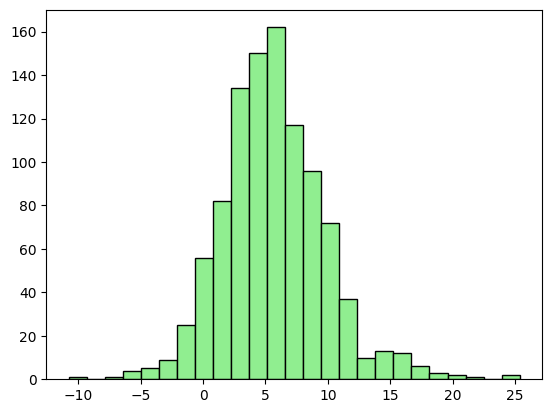

In [24]:
import matplotlib.pyplot as plt

plt.hist(Y, bins=25, color='lightgreen', edgecolor='black')

In [26]:
np.median(Y)

5.5203553484032835

In [28]:
Y1 = np.where(Y >= np.median(Y), 1, 0)

In [35]:
from scipy.special import expit
Y_prawdopodobienstwo = expit(Y)

Y2 = np.where(Y_prawdopodobienstwo >= 0.5, 1, 0)

In [36]:
Y2

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,

In [42]:
roznice_df = df_istotne[Y1 != Y2]
(Y1 != Y2).sum()

432